# 📰 Task 1 — Fake News Detection System

Build a machine learning model that classifies news articles as **REAL** or **FAKE**.

**Pipeline**
1. Collect a labeled dataset of news headlines/articles
2. Clean & preprocess the text (tokenization, stop word removal, TF-IDF)
3. Train classifiers — Logistic Regression, Random Forest, Naive Bayes
4. Evaluate accuracy
5. Wrap the best model in a simple interface for instant predictions

> The interactive "paste a headline, get a prediction" interface lives in **`app.py`** (Streamlit). This notebook covers steps 1–4 and prepares the model that `app.py` loads.

## Setup

In [1]:
import re
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for pkg, path in [("punkt", "tokenizers/punkt"),
                   ("punkt_tab", "tokenizers/punkt_tab"),
                   ("stopwords", "corpora/stopwords")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)

print("Setup complete.")

Setup complete.


## 1. Load & Explore the Dataset

We use a labeled dataset of ~4,600 real-world news articles (title + body text), evenly split
between `REAL` (from mainstream outlets such as Reuters) and `FAKE` (from known fake-news sites).
Source: [`GeorgeMcIntire/fake_real_news_dataset`](https://github.com/GeorgeMcIntire/fake_real_news_dataset),
used in the widely-cited *"How to Build a 'Fake News' Classification Model"* tutorial.

In [2]:
df = pd.read_csv("data/news.csv")
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
df["label"] = df["label"].str.upper().str.strip()

print(f"Shape: {df.shape}")
df[["title", "text", "label"]].head()

Shape: (4594, 4)


,title,text,label
0,‘A target on Roe v. Wade ’: Oklahoma bill maki...,UPDATE: Gov. Fallin vetoed the bill on Friday....,REAL
1,Study: women had to drive 4 times farther afte...,Ever since Texas laws closed about half of the...,REAL
2,"Trump, Clinton clash in dueling DC speeches","Donald Trump and Hillary Clinton, now at the s...",REAL
3,Grand jury in Texas indicts activists behind P...,A Houston grand jury investigating criminal al...,REAL
4,"As Reproductive Rights Hang In The Balance, De...",WASHINGTON -- Forty-three years after the Supr...,REAL


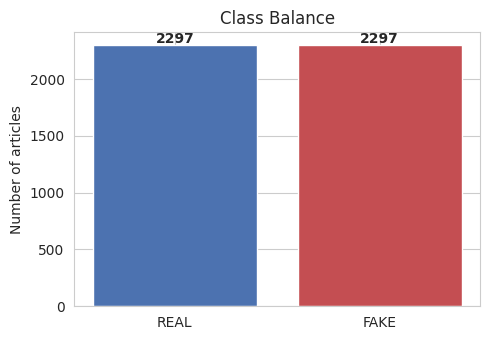

label
REAL    2297
FAKE    2297


In [3]:
fig, ax = plt.subplots(figsize=(5, 3.5))
counts = df["label"].value_counts()
colors = ["#4C72B0" if lbl == "REAL" else "#C44E52" for lbl in counts.index]
ax.bar(counts.index, counts.values, color=colors)
ax.set_title("Class Balance")
ax.set_ylabel("Number of articles")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(counts.to_string())

## 2. Text Preprocessing

For each article we combine `title + text` into one field, then:

1. Lowercase everything
2. Strip URLs and HTML tags
3. Keep only letters (drop punctuation/digits)
4. **Tokenize** with NLTK's word tokenizer
5. **Remove stop words** (and very short tokens)

This exact function also lives in `preprocess.py`, shared with `train_model.py` and `app.py` so
that live user input is cleaned identically to the training data.

In [4]:
STOPWORDS = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return " ".join(tokens)

# demo on one article
sample_raw = (df["title"] + " " + df["text"]).iloc[0]
print("BEFORE:", sample_raw[:200], "...\n")
print("AFTER: ", clean_text(sample_raw)[:200], "...")

BEFORE: ‘A target on Roe v. Wade ’: Oklahoma bill making it a felony to perform abortions waits for governor’s decision UPDATE: Gov. Fallin vetoed the bill on Friday. Head here for more.

Lawmakers in Oklahom ...

AFTER:  target roe wade oklahoma bill making felony perform abortions waits governor decision update gov fallin vetoed bill friday head lawmakers oklahoma approved bill thursday would make performing abortion ...


In [5]:
df["content"] = (df["title"] + " " + df["text"]).str.strip()
df["clean"] = df["content"].apply(clean_text)
df = df[df["clean"].str.len() > 0].reset_index(drop=True)
print(f"{len(df)} articles remain after cleaning.")
df[["content", "clean", "label"]].head(3)

4594 articles remain after cleaning.


,content,clean,label
0,‘A target on Roe v. Wade ’: Oklahoma bill maki...,target roe wade oklahoma bill making felony pe...,REAL
1,Study: women had to drive 4 times farther afte...,study women drive times farther texas laws clo...,REAL
2,"Trump, Clinton clash in dueling DC speeches Do...",trump clinton clash dueling speeches donald tr...,REAL


## 3. Feature Engineering: TF-IDF Vectorization

We split into train/test sets first, then fit a **TF-IDF** vectorizer (unigrams + bigrams,
top 5,000 features) on the training text only, to avoid leaking test-set vocabulary statistics
into training.

In [6]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean"], df["label"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"],
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Train: (3675, 5000)  |  Test: (919, 5000)
Vocabulary size: 5000


## 4. Train Classification Models

We train three classic classifiers on the TF-IDF features and compare them head-to-head:

- **Logistic Regression** — strong, well-calibrated linear baseline for sparse text features
- **Random Forest** — ensemble of decision trees, captures non-linear feature interactions
- **Multinomial Naive Bayes** — classic, fast text-classification baseline

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    "Naive Bayes": MultinomialNB(),
}

results = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = accuracy_score(y_test, preds)
    print(f"{name}: accuracy = {results[name]:.4f}")

Logistic Regression: accuracy = 0.9249


Random Forest: accuracy = 0.9206
Naive Bayes: accuracy = 0.8868


## 5. Model Evaluation

In [8]:
for name in models:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, predictions[name]))

Logistic Regression
              precision    recall  f1-score   support

        FAKE       0.91      0.95      0.93       460
        REAL       0.94      0.90      0.92       459

    accuracy                           0.92       919
   macro avg       0.93      0.92      0.92       919
weighted avg       0.93      0.92      0.92       919

Random Forest
              precision    recall  f1-score   support

        FAKE       0.92      0.92      0.92       460
        REAL       0.92      0.92      0.92       459

    accuracy                           0.92       919
   macro avg       0.92      0.92      0.92       919
weighted avg       0.92      0.92      0.92       919

Naive Bayes
              precision    recall  f1-score   support

        FAKE       0.88      0.90      0.89       460
        REAL       0.89      0.88      0.89       459

    accuracy                           0.89       919
   macro avg       0.89      0.89      0.89       919
weighted avg       0.89     

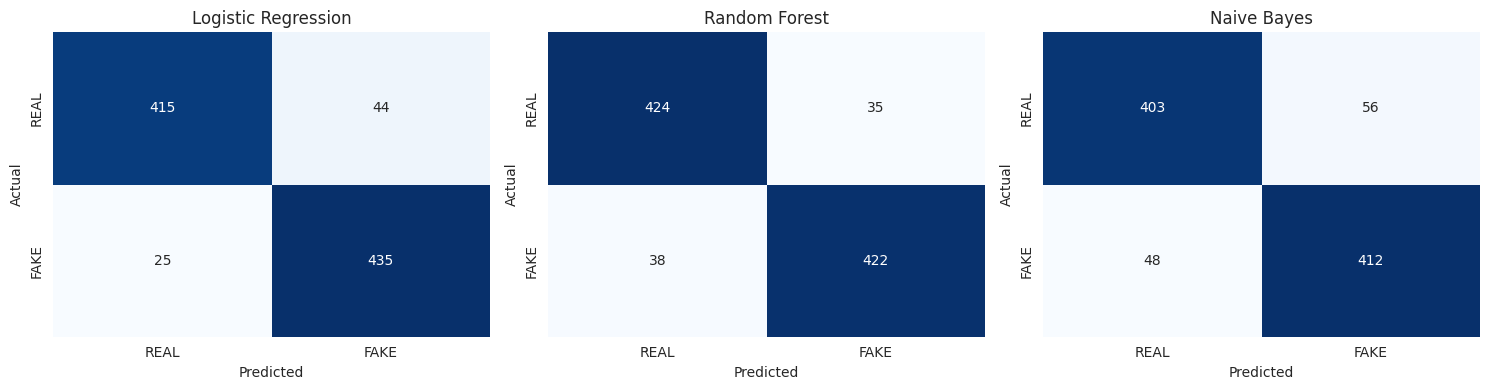

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name], labels=["REAL", "FAKE"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

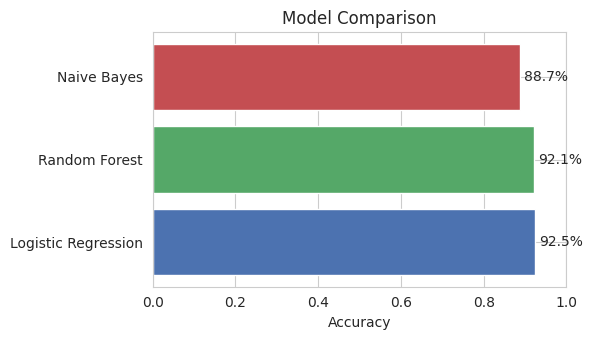

Best model: Logistic Regression  (92.49% accuracy)


In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
names = list(results.keys())
accs = [results[n] for n in names]
bars = ax.barh(names, accs, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Model Comparison")
for bar, acc in zip(bars, accs):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height()/2, f"{acc:.1%}", va="center")
plt.tight_layout()
plt.show()

best_name = max(results, key=results.get)
print(f"Best model: {best_name}  ({results[best_name]:.2%} accuracy)")

## 6. Save the Best Model

We persist the winning model and the fitted TF-IDF vectorizer so the interface (`app.py`) can
load them instantly without retraining.

In [11]:
from pathlib import Path

MODEL_DIR = Path("model")
MODEL_DIR.mkdir(exist_ok=True)

best_model = models[best_name]
joblib.dump(best_model, MODEL_DIR / "model.pkl")
joblib.dump(vectorizer, MODEL_DIR / "vectorizer.pkl")
with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump({"best_model": best_name, "accuracies": results}, f, indent=2)

print(f"Saved to {MODEL_DIR}/: model.pkl, vectorizer.pkl, metadata.json")

Saved to model/: model.pkl, vectorizer.pkl, metadata.json


## 7. Instant Prediction

A quick preview of the same logic that powers the interface: clean the pasted text, vectorize
it, and predict. Run **`streamlit run app.py`** for the full interactive version with a text box
and confidence bars.

In [12]:
def predict_news(text: str) -> dict:
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = best_model.predict(vec)[0]
    proba = dict(zip(best_model.classes_, best_model.predict_proba(vec)[0])) \
        if hasattr(best_model, "predict_proba") else None
    return {"prediction": pred, "confidence": proba}

examples = [
    "Scientists confirm the moon is actually a hologram projected by NASA to hide the truth",
    "Federal Reserve raises interest rates by a quarter point amid inflation concerns",
]

for headline in examples:
    result = predict_news(headline)
    print(f"Headline: {headline}")
    print(f"  -> {result['prediction']}", {k: round(float(v), 3) for k, v in result["confidence"].items()})
    print()

Headline: Scientists confirm the moon is actually a hologram projected by NASA to hide the truth
  -> FAKE {'FAKE': 0.928, 'REAL': 0.072}

Headline: Federal Reserve raises interest rates by a quarter point amid inflation concerns
  -> FAKE {'FAKE': 0.751, 'REAL': 0.249}



## 8. Conclusion & Limitations

- The best model (**Logistic Regression**, on this split) reached **~92% test accuracy** on this
  dataset using only TF-IDF + classical ML — no deep learning required.
- **This is a demonstration model, not a fact-checker.** It learned lexical/stylistic patterns
  (word choice, phrasing) from ~4,600 articles collected mostly around 2016, so it can be
  confidently wrong on topics, outlets, or writing styles outside that training distribution —
  see the Fed-rates example above.
- **Next steps** to make this more robust: train on a larger and more diverse/recent dataset,
  add source/metadata features, try word embeddings or a transformer model (e.g. DistilBERT),
  and calibrate/monitor the model over time as misinformation tactics evolve.